In [258]:
library(rsample)     # data splitting 
library(dplyr)       # data wrangling
library(rpart)       # performing regression trees
library(janitor)
library(readr)
library(tidyverse)
library(xgboost)
library(rPref)
library(caret)
library(geometry)

### Constants

In [219]:
def_outbreak <- 2       # number of cases to be considered and outbreak
perc_strata <- 0.75  # training/test split

### Creating data with no filtering or SMOTE

In [220]:
set.seed(100)
# Choose which dataset to use for testing 
#df <- read_csv("data/merged_data.csv", show_col_types = FALSE) |> clean_names() 
df <- read_csv("data/merged_with_svi.csv", show_col_types = FALSE) |> clean_names()

df$outbreak <- as.integer(df$outbreak >= def_outbreak)

# SVI specific, because it does not include the data for Mcculloch, Mclennan, Mcmullen and Dewitt, 
# if we continue the prev way of data processing it will remove all SVI related features, so we remove these 4 counties.
df <- df[!df$county %in% c("Mcculloch", "Mclennan", "Mcmullen", "Dewitt"), ]

# split the data with stratified sampling
#strata <- ifelse(df$outbreak > 0, "nonzero", "zero")
index <- createDataPartition(df$outbreak, p = perc_strata, list = FALSE)
train <- df[index,]
test <- df[-index,]

train <- train[, !names(train) %in% c("county")]
test <- test[, !names(test) %in% c("county")]


### Xgboost Model

In [221]:
set.seed(100)
cutoff = 0.5

X_train <- as.matrix(train[, names(train) != "outbreak"])
y_train <- as.numeric(as.character(train$outbreak))

X_test  <- as.matrix(test[, names(test) != "outbreak"])
y_test  <- as.numeric(as.character(test$outbreak))

dtrain  <- xgb.DMatrix(data = X_train, label = y_train)
dtest   <- xgb.DMatrix(data = X_test,  label = y_test)

boost_model <- xgb.train(
  params = list(
    objective   = "binary:logistic",
    eval_metric = "logloss"
  ),
  data    = dtrain,
  nrounds = 500
)

pred_xgb <- as.integer(predict(boost_model, dtest)>= cutoff)

boost_table <- table(Actual = y_test, Predicted = pred_xgb)
boost_table

# importance graph
importance_matrix <- xgb.importance(model = boost_model)
#xgb.plot.importance(importance_matrix)
#importance_matrix[order(importance_matrix$Gain, decreasing = TRUE)]

# Summary of first tree model
# tree_df <- xgb.model.dt.tree(model = boost_model)
# print(tree_df[Tree == 0, ])

TP <- boost_table[2, 2] # True Positives (Actual Outbreak, Predicted Outbreak)
TN <- boost_table[1, 1] # True Negatives (Actual No Outbreak, Predicted No Outbreak)
FP <- boost_table[1, 2] # False Positives (Actual No Outbreak, Predicted Outbreak)
FN <- boost_table[2, 1] # False Negatives (Actual Outbreak, Predicted No Outbreak)

accuracy    <- (TP + TN) / sum(boost_table)
recall <- TP / (TP + FN) 
precision   <- TP / (TP + FP)

cat("Model Performance Summary (Cutoff = 0.5):\n",
    "Accuracy (Overall Correctness): ", round(accuracy, 4), "\n",
    "Recall (Outbreak Capture Rate): ", round(recall, 4), "\n",
    "Precision (Reliability of Outbreak Prediction): ", round(precision, 4), "\n")

      Predicted
Actual  0  1
     0 53  1
     1  7  1

Model Performance Summary (Cutoff = 0.5):
 Accuracy (Overall Correctness):  0.871 
 Recall (Outbreak Capture Rate):  0.125 
 Precision (Reliability of Outbreak Prediction):  0.5 


### Parameter Tuning

In [222]:
set.seed(100)
# Xgboost 
c_xgb <- c(seq(0.2, 0.5, by=0.1))      # deciding what counts as outbreak
max_depth = c(seq(3, 9, by=2))         # max depth of each tree 
eta = c(0.01,seq(0.05, 0.4, by=0.05))  # learning rate

# Create grid
param_grid <- expand.grid(
  max_depth = max_depth,
  eta = eta,
  cutoff = c_xgb
)

# Create folds for testing
folds <- createFolds(train$outbreak, k=10)

### Cross validation w/ parameter tuning

In [223]:
set.seed(100)
results_xgb <- data.frame()

for(i in 1:nrow(param_grid)){
  fold_precision <- c()
  fold_recall    <- c()
  fold_accuracy  <- c()
    
  for(fold in folds){
    fold_train <- train[-fold, ]
    fold_test  <- train[fold, ]

    X_fold_train <- as.matrix(fold_train[, names(fold_train) != "outbreak"])
    y_fold_train <- as.numeric(as.character(fold_train$outbreak))
    X_fold_test  <- as.matrix(fold_test[, names(fold_test) != "outbreak"])
    y_fold_test  <- as.numeric(as.character(fold_test$outbreak))

    dtrain_fold <- xgb.DMatrix(data = X_fold_train, label = y_fold_train)
    dtest_fold  <- xgb.DMatrix(data = X_fold_test,  label = y_fold_test)

    model <- xgb.train(
      params = list(
        objective   = "binary:logistic",
        eval_metric = "logloss",
        max_depth   = param_grid$max_depth[i],
        eta         = param_grid$eta[i]
      ),
      data    = dtrain_fold,
      nrounds = 500,
      verbose = 0
    )

    preds <- as.numeric(predict(model, dtest_fold) >= param_grid$cutoff[i])

    # build full 2x2 confusion matrix even if a class is missing
    cm <- table(
      factor(fold_test$outbreak, levels = c(0, 1)),
      factor(preds,              levels = c(0, 1))
    )

    tp <- cm[2, 2]
    fp <- cm[1, 2]
    fn <- cm[2, 1]

    precision <- if((tp + fp) == 0) NA else tp / (tp + fp)
    recall    <- if((tp + fn) == 0) NA else tp / (tp + fn)
    accuracy  <- sum(diag(cm)) / sum(cm)

    fold_precision <- c(fold_precision, precision)
    fold_recall    <- c(fold_recall,    recall)
    fold_accuracy  <- c(fold_accuracy,  accuracy)
  }

  # outside inner loop
  results_xgb <- rbind(results_xgb, data.frame(
    max_depth     = param_grid$max_depth[i],
    eta           = param_grid$eta[i],
    cutoff        = param_grid$cutoff[i],
    precision     = mean(fold_precision, na.rm = TRUE),
    precision_std = sd(fold_precision,   na.rm = TRUE),
    recall        = mean(fold_recall,    na.rm = TRUE),
    recall_std    = sd(fold_recall,      na.rm = TRUE),
    accuracy      = mean(fold_accuracy,  na.rm = TRUE),
    accuracy_std  = sd(fold_accuracy,    na.rm = TRUE)
  ))
}

best_xgb <- results_xgb[which.max(results_xgb$recall), ]
print(best_xgb)

  max_depth eta cutoff precision precision_std    recall recall_std  accuracy
9         3 0.1    0.2 0.4166667      0.390868 0.4074074  0.4937886 0.9201754
  accuracy_std
9   0.05135352


### Evaluation best parameters

In [234]:
p_xgb <- high(precision, df = results_xgb) * high(recall) * high(accuracy)
res_xgb <- psel(results_xgb, p_xgb)

# Create the actual convex hull for the full results vector
hull_mat <- as.matrix(results_xgb[, c("precision", "recall", "accuracy")])
hull_idx <- convhulln(hull_mat) 

# hull_idx is a dataframe of triangles (surface) that encapsulate all points
# find only the unique values so they all connect
unique_indices <- unique(as.vector(hull_idx))
results_hull <- results_xgb[unique_indices, ]

# Take only intersecting points of the data
intersecting_points <- merge(results_hull, res_xgb)
res_xgb <- intersecting_points[order(intersecting_points$precision), ]
res_xgb

,max_depth,eta,cutoff,precision,precision_std,recall,recall_std,accuracy,accuracy_std
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3,0.10,0.2,0.4166667,0.3908680,0.4074074,0.4937886,0.9201754,0.05135352
2,3,0.40,0.4,0.5000000,0.0000000,0.1481481,0.3379313,0.9254386,0.04473355
3,5,0.01,0.4,0.5000000,0.3535534,0.3703704,0.4843221,0.9201754,0.05703295


### Evaluating Optimized parameter metrics

In [257]:
set.seed(100)

# Setting optimal parameters
max_depth = 3
eta = 0.4
cutoff = 0.4

# Create matricies for xgboost 
X_train <- as.matrix(train[, names(train) != "outbreak"])
y_train <- as.numeric(as.character(train$outbreak))

X_test  <- as.matrix(test[, names(test) != "outbreak"])
y_test  <- as.numeric(as.character(test$outbreak))

dtrain  <- xgb.DMatrix(data = X_train, label = y_train)
dtest   <- xgb.DMatrix(data = X_test,  label = y_test)


# Train model with parameters
final_model <- xgb.train(
  params = list(
    objective   = "binary:logistic",
    eval_metric = "logloss",
    eta = eta, 
    max_depth = max_depth
  ),
  data    = dtrain,
  nrounds = 500
)

# Predict on test set and display results
pred_xgb <- as.integer(predict(final_model, dtest)>= cutoff)
boost_table <- table(Actual = y_test, Predicted = pred_xgb)
boost_table

# Calculate Precision, Accuracy, and recall
TP <- boost_table[2, 2] # True Positives 
TN <- boost_table[1, 1] # True Negatives 
FP <- boost_table[1, 2] # False Positives 
FN <- boost_table[2, 1] # False Negatives 

accuracy    <- (TP + TN) / sum(boost_table) # total accuracy
recall <- TP / (TP + FN)                    # amount of positives guessed correctly out of all true positives
precision   <- TP / (TP + FP)               # amount of correct positive predictions

cat("Model Performance Summary:\n",
    "Accuracy (Overall Correctness): ", round(accuracy, 4), "\n",
    "Recall (Outbreak Capture Rate): ", round(recall, 4), "\n",
    "Precision (Reliability of Outbreak Prediction): ", round(precision, 4), "\n")


#         Predicted
# Actual  0  1
#      0 48  9
#      1  1  4


      Predicted
Actual  0  1
     0 53  1
     1  7  1

Model Performance Summary:
 Accuracy (Overall Correctness):  0.871 
 Recall (Outbreak Capture Rate):  0.125 
 Precision (Reliability of Outbreak Prediction):  0.5 


### Investigating False Results

In [255]:
# Looking at if false negatives is consistent with other classification methods
false_negatives <- test[test$outbreak == 1 & pred_xgb == 0, ]
false_negatives # IS the same county (upshur)


cve,outbreak,enrollment,population,phr,pct_hispanic,pct_black,pct_white,pct_poverty,pct_uninsured,⋯,ep_asian,mp_asian,ep_aian,mp_aian,ep_nhpi,mp_nhpi,ep_twomore,mp_twomore,ep_otherrace,mp_otherrace
<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.80,1,1330,7057,1,66.0,0.9,71.3,7.4,28.6,⋯,1.3,0.8,1.0,0.9,0.0,0.7,1.4,1.4,0.0,0.7
2.06,1,2071,7831,1,54.3,0.2,50.9,10.7,24.4,⋯,0.0,0.7,0.0,0.7,0.0,0.7,3.3,1.7,1.5,1.7
3.99,1,2515,18223,2,17.3,2.2,80.8,10.5,15.3,⋯,0.4,0.3,0.4,0.5,0.0,0.3,1.9,0.8,0.2,0.3
1.30,1,5789,31802,1,61.3,4.6,52.6,15.9,21.0,⋯,0.6,0.1,0.1,0.1,0.1,0.1,1.8,0.6,0.2,0.2
3.24,1,8516,12620,4,9.6,12.1,75.1,15.7,19.3,⋯,0.9,0.2,0.7,0.3,0.2,0.4,4.3,0.9,0.1,0.1
1.07,1,2164,9288,1,66.7,0.3,64.0,8.9,24.1,⋯,0.0,0.5,0.3,0.5,0.0,0.5,1.5,0.7,0.2,0.4
5.00,1,7416,44174,4,10.4,7.2,79.3,10.1,13.8,⋯,0.5,0.1,0.1,0.1,0.1,0.1,3.3,0.6,0.2,0.2


### Looking at splits for optimzied tree

In [252]:
# Extract all trees into df 
tree_summary <- xgb.model.dt.tree(model = final_model)

# look at first tree
first_tree <- tree_summary[Tree == 5]
first_tree

#false_negatives[, c("any_cancer_no", "spl_theme2", "e_unemp", "cve")]

# SVI documentation: https://www.atsdr.cdc.gov/place-health/media/pdfs/2024/10/SVI2022Documentation.pdf
# any_cancer_no: does not have cancer
# enrollment: percentage of kinds enrolled in school
# m_hh: house holds estimate margin of error? 
# ep_aian: Percentage of American Indian or Alaska Native, not Hispanic or Latino persons estimate, 

# Guide on how to read text dump: 
# look at a given feature (x) then split number (y)
# all formulas will be in the form x < y 
# given this look at the yes or no column the right value is the node that it will traverse to next

# Gain (for non-leaf nodes): "importance level" arbitrary value to determine value 
# Gain (for leaf nodes): probability increase/decrease of outbreak (sigmoid log odds of it happening)
# Cover: the average number of observations effected by this feature to split 

Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover
<int>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
4,0,4-0,ep_hisp,36.80,4-1,4-2,4-2,2.641143800,9.478434
4,1,4-1,fobt_past_yr_yes,9.80,4-3,4-4,4-4,0.422574639,3.676489
4,2,4-2,cve,1.82,4-5,4-6,4-6,2.542674300,5.801945
4,3,4-3,Leaf,NA,NA,NA,NA,-0.009832857,1.000575
4,4,4-4,Leaf,NA,NA,NA,NA,-0.313278973,2.675913
4,5,4-5,Leaf,NA,NA,NA,NA,-0.177602366,1.939054
4,6,4-6,m_groupq,20.00,4-7,4-8,4-8,0.668307543,3.862892
4,7,4-7,Leaf,NA,NA,NA,NA,0.024385473,1.210082
4,8,4-8,Leaf,NA,NA,NA,NA,0.389259338,2.652810


### Looking into m_hh (house hold estimate margin or error)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   25.0   149.2   259.0   381.8   442.8  4042.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     38    2094    6652   41542   18019 1692896 

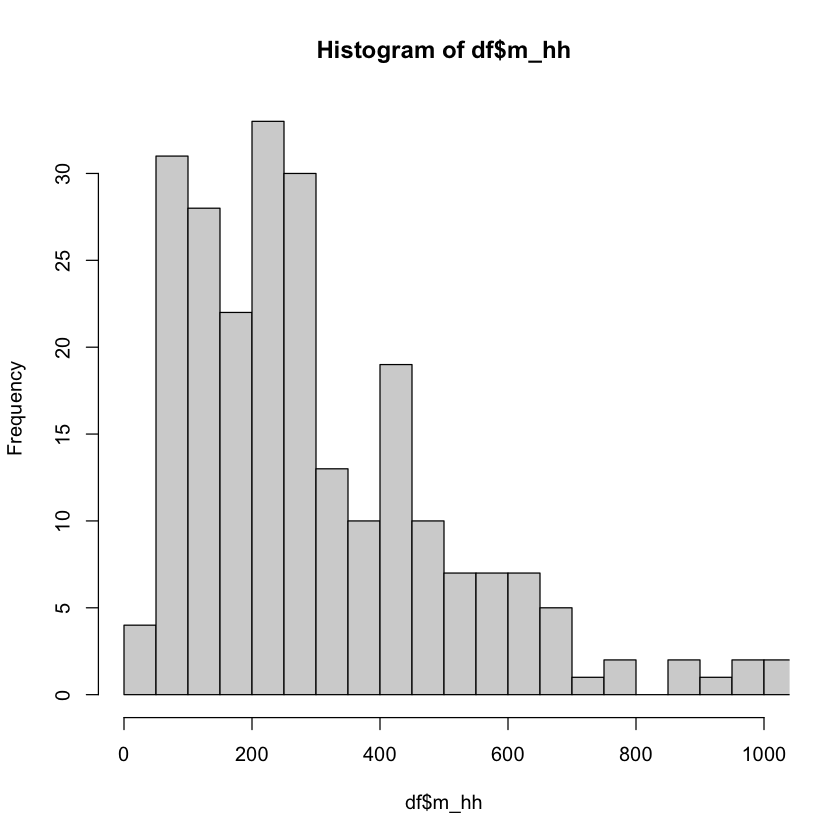

In [243]:
# Household estimate is the amount of housing units that are in a given population 
# We try to look into the variance of the this variable
# I just realized that this i the first 

# Look at margin of error
summary(df$m_hh)
#hist(df$m_hh, breaks = 100)

# Closer look into MOE 
hist(df$m_hh, breaks = 100, xlim = c(0, 1000))

# Look at actual household estimate 
summary(df$e_hh)
# hist(df$e_hh)

### Look at all features used in the model

In [244]:
# importance graph
# Gain: the average imporvement in the models accuracy when the feature is used to split 
# Cover: The average number of observations effected by this feature to split 
# Frequency: The percentage of times a feature is chosen to split the data accross all trees

importance_matrix <- xgb.importance(model = boost_model)
#head(importance_matrix[order(importance_matrix$Gain, decreasing = TRUE)], 10)
importance_matrix

# Print all features used in the boosted tree
# print(importance_matrix[order(importance_matrix$Gain, decreasing = TRUE)])

# List of most important features: 
# Any_cancer_no: has cancer - greater people with cancer highly correlated 
# Enrollment: not sure 
# ep_age17: amount of people age 17 or under 
# spl_theme1: sum of socioeconomic status indicators
# ep_limeng: amount of limited english speakers
# m_limeng: margin of error ^
# sigm_and_blood_still_50_70_i_no: unsure 
# e_munit: multi unit housing 
# cve: concious exemption rate 
# ep_aian: Native american percentage 
# e_groupq: Persons in group quarter

Feature,Gain,Cover,Frequency
<chr>,<dbl>,<dbl>,<dbl>
any_cancer_no,0.2102878984,0.074568254,0.027397260
e_unemp,0.1483146888,0.007127674,0.006849315
cve,0.1097711710,0.071594019,0.075342466
ep_hisp,0.0858808127,0.089233563,0.068493151
ep_age65,0.0779714169,0.067349883,0.047945205
pct_black,0.0509594320,0.031980664,0.020547945
ep_unemp,0.0395418777,0.016718772,0.013698630
mammogram_no,0.0375615050,0.044676216,0.020547945
m_age65,0.0359659170,0.084273722,0.075342466


### Look at intersecting features from removed na data and no removed na data

In [262]:
no_NA_features <- c('poor_mental_health_14_days_14_or_more_days', 'pct_black', 'mammogram_no', 'pct_hispanic', 'bp_sharing_in_person', 
'cve', 'bmi_4_categories_recommended_range', 'pct_college', 'arthritis_no', 'pct_white', 'population', 'advised_to_change_eating_hab_no', 
'any_cancer_no', 'chest_ct_or_cat_scan_no', 'phr', 'pct_poverty', 'e_cig_ever_not_at_all_right_now', 'pct_foreign_born', 'pain_med_not_rx_no', 
'advised_to_exercise_no', 'hlth_affected_activ_5_days_5_or_more_days', 'pneumonia_shot_65_no', 'e_cig_ever_never_used_e_cigarettes',
'pct_uninsured', 'sigm_past_5_yrs_50_75_ia_no', 'poor_mental_health_5_days_5_or_more_days', 'general_health_fair', 'teeth_removed_no',
'ever_had_sgmscpy_clnscpy_no', 'poor_physical_health_14_day_14_or_more_days', 'bmi_5_categories_obese', 'leisure_time_pa_no',
'advised_to_cut_down_salt_no', 'mammogram_past_2_yrs_50_ia_no', 'general_health_excellent', 'last_dentist_visit_within_the_past_5_years', 
'heart_attack_no', 'bp_location_at_home','ever_had_blood_stool_test_yes', 'difficulty_dressing_no', 'heavy_drinking_no', 
'bmi_3_categories_recommended_range', 'skin_cancer_no', 'mammogram_past_2_yrs_50_74_i_yes', 'sigm_past_10_yrs_age_50_75_no', 
'bmi_3_categories_overweight')

yes_NA_features <- importance_matrix$Feature

# Notice most of the important features are used in the models, at least for the yes NA features model
intersected_features <- intersect(no_NA_features, yes_NA_features)
print(intersected_features)

[1] "pct_black"                                
[2] "mammogram_no"                             
[3] "cve"                                      
[4] "any_cancer_no"                            
[5] "hlth_affected_activ_5_days_5_or_more_days"
[6] "bmi_3_categories_recommended_range"       
[7] "bmi_3_categories_overweight"              
